In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "Judgement ⑪ scored coded values at ~28% agreement by Jaccard set-overlap. How much of that was a *measurement artifact* (right value, different phrasing) versus a genuine coding error — and which fields are which?"

*A re-score of ⑪ using an Opus semantic-equivalence judge on the same codings. This decides whether the fix is normalization (a formatting problem) or something deeper.*

In [2]:

import json
from collections import defaultdict

REJ = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_rejudge.json", encoding="utf-8"))
COD = json.load(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/validation/j11_coding_runs.json", encoding="utf-8"))
verd = {(v["model"], v["sample_id"], v["field"]): v["verdict"] for v in REJ["verdicts"]}
GOLD = {g["sample_id"]: g["fields"] for g in COD["gold"]}
FIELDS = COD["manifest"]["fields"]; CAND = COD["manifest"]["candidate_models"]
PRICES = {'thinkingmachines/inkling': 1.0, 'openrouter/auto-beta': -1000000.0, 'moonshotai/kimi-k3': 3.0, 'meta/muse-spark-1.1': 1.25, 'kwaipilot/kat-coder-air-v2.5': 0.15, 'kwaipilot/kat-coder-pro-v2.5': 0.74, 'openai/gpt-5.6-luna-pro': 1.0, 'openai/gpt-5.6-luna': 1.0, 'openai/gpt-5.6-terra-pro': 2.5, 'openai/gpt-5.6-terra': 2.5, 'openai/gpt-5.6-sol-pro': 5.0, 'openai/gpt-5.6-sol': 5.0, 'x-ai/grok-4.5': 2.0, '~x-ai/grok-latest': 2.0, 'aion-labs/aion-3.0-mini': 0.7, 'aion-labs/aion-3.0': 3.0, 'tencent/hy3': 0.2, 'tencent/hy3:free': 0.0, 'poolside/laguna-xs-2.1': 0.06, 'poolside/laguna-xs-2.1:free': 0.0, 'anthropic/claude-sonnet-5': 2.0, 'google/gemini-3.1-flash-lite-image': 0.25, 'nex-agi/nex-n2-mini': 0.025, 'sakana/fugu-ultra': 5.0, 'google/gemini-3.1-flash-image': 0.5, 'google/gemini-3-pro-image': 2.0, 'cohere/north-mini-code:free': 0.0, 'z-ai/glm-5.2': 0.416, 'openrouter/fusion': -1000000.0, 'moonshotai/kimi-k2.7-code': 1.0, '~anthropic/claude-fable-latest': 10.0, 'anthropic/claude-fable-5': 10.0, 'nex-agi/nex-n2-pro': 0.25, 'nvidia/nemotron-3.5-content-safety:free': 0.0, 'nvidia/nemotron-3-ultra-550b-a55b': 0.6, 'nvidia/nemotron-3-ultra-550b-a55b:free': 0.0, 'qwen/qwen3.7-plus': 0.32, 'minimax/minimax-m3': 0.3, 'stepfun/step-3.7-flash': 0.2, 'anthropic/claude-opus-4.8-fast': 10.0, 'anthropic/claude-opus-4.8': 5.0, 'qwen/qwen3.7-max': 1.475, 'x-ai/grok-build-0.1': 1.0, 'google/gemini-3.5-flash': 1.5, 'anthropic/claude-opus-4.7-fast': 30.0, 'perceptron/perceptron-mk1': 0.15, 'inclusionai/ring-2.6-1t': 0.075, 'google/gemini-3.1-flash-lite': 0.25, 'openai/gpt-chat-latest': 5.0, 'x-ai/grok-4.3': 1.25, 'ibm-granite/granite-4.1-8b': 0.05, 'mistralai/mistral-medium-3-5': 1.5, 'nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free': 0.0, 'poolside/laguna-m.1': 0.2, 'poolside/laguna-m.1:free': 0.0, '~anthropic/claude-haiku-latest': 1.0, '~openai/gpt-mini-latest': 0.75, '~google/gemini-pro-latest': 2.0, '~moonshotai/kimi-latest': 3.0, '~google/gemini-flash-latest': 1.5, '~anthropic/claude-sonnet-latest': 2.0, '~openai/gpt-latest': 5.0, 'qwen/qwen3.5-plus-20260420': 0.3, 'qwen/qwen3.6-flash': 0.188, 'qwen/qwen3.6-35b-a3b': 0.14, 'qwen/qwen3.6-max-preview': 1.04, 'qwen/qwen3.6-27b': 0.45, 'openai/gpt-5.5-pro': 30.0, 'openai/gpt-5.5': 5.0, 'deepseek/deepseek-v4-pro': 0.435, 'deepseek/deepseek-v4-flash': 0.098, 'inclusionai/ling-2.6-1t': 0.075, 'tencent/hy3-preview': 0.063, 'xiaomi/mimo-v2.5-pro': 0.435, 'xiaomi/mimo-v2.5': 0.14, 'openai/gpt-5.4-image-2': 8.0, 'inclusionai/ling-2.6-flash': 0.01, '~anthropic/claude-opus-latest': 5.0, 'openrouter/pareto-code': -1000000.0, 'moonshotai/kimi-k2.6': 0.95, 'anthropic/claude-opus-4.7': 5.0, 'z-ai/glm-5.1': 0.966, 'google/gemma-4-26b-a4b-it': 0.1, 'google/gemma-4-26b-a4b-it:free': 0.0, 'google/gemma-4-31b-it': 0.22, 'google/gemma-4-31b-it:free': 0.0, 'qwen/qwen3.6-plus': 0.325, 'z-ai/glm-5v-turbo': 1.2, 'arcee-ai/trinity-large-thinking': 0.25, 'x-ai/grok-4.20-multi-agent': 1.25, 'x-ai/grok-4.20': 1.25, 'google/lyria-3-pro-preview': 0.0, 'google/lyria-3-clip-preview': 0.0, 'kwaipilot/kat-coder-pro-v2': 0.3, 'rekaai/reka-edge': 0.1, 'minimax/minimax-m2.7': 0.25, 'openai/gpt-5.4-nano': 0.2, 'openai/gpt-5.4-mini': 0.75, 'mistralai/mistral-small-2603': 0.15, 'z-ai/glm-5-turbo': 1.2, 'nvidia/nemotron-3-super-120b-a12b': 0.21, 'nvidia/nemotron-3-super-120b-a12b:free': 0.0, 'bytedance-seed/seed-2.0-lite': 0.25, 'qwen/qwen3.5-9b': 0.1, 'openai/gpt-5.4-pro': 30.0, 'openai/gpt-5.4': 2.5, 'inception/mercury-2': 0.25, 'openai/gpt-5.3-chat': 1.75, 'google/gemini-3.1-flash-lite-preview': 0.25, 'bytedance-seed/seed-2.0-mini': 0.1, 'google/gemini-3.1-flash-image-preview': 0.5, 'qwen/qwen3.5-35b-a3b': 0.14, 'qwen/qwen3.5-27b': 0.26, 'qwen/qwen3.5-122b-a10b': 0.26, 'qwen/qwen3.5-flash-02-23': 0.065, 'google/gemini-3.1-pro-preview-customtools': 2.0, 'openai/gpt-5.3-codex': 1.75, 'aion-labs/aion-2.0': 0.8, 'google/gemini-3.1-pro-preview': 2.0, 'anthropic/claude-sonnet-4.6': 3.0, 'qwen/qwen3.5-plus-02-15': 0.26, 'qwen/qwen3.5-397b-a17b': 0.39, 'minimax/minimax-m2.5': 0.15, 'z-ai/glm-5': 0.95, 'qwen/qwen3-max-thinking': 0.78, 'anthropic/claude-opus-4.6': 5.0, 'qwen/qwen3-coder-next': 0.11, 'openrouter/free': 0.0, 'stepfun/step-3.5-flash': 0.1, 'moonshotai/kimi-k2.5': 0.57, 'upstage/solar-pro-3': 0.15, 'minimax/minimax-m2-her': 0.3, 'writer/palmyra-x5': 0.6, 'openai/gpt-audio': 2.5, 'openai/gpt-audio-mini': 0.6, 'z-ai/glm-4.7-flash': 0.061, 'openai/gpt-5.2-codex': 1.75, 'bytedance-seed/seed-1.6-flash': 0.075, 'bytedance-seed/seed-1.6': 0.25, 'minimax/minimax-m2.1': 0.3, 'z-ai/glm-4.7': 0.4, 'google/gemini-3-flash-preview': 0.5, 'nvidia/nemotron-3-nano-30b-a3b': 0.05, 'nvidia/nemotron-3-nano-30b-a3b:free': 0.0, 'openai/gpt-5.2-chat': 1.75, 'openai/gpt-5.2-pro': 21.0, 'openai/gpt-5.2': 1.75, 'mistralai/devstral-2512': 0.4, 'relace/relace-search': 1.0, 'z-ai/glm-4.6v': 0.3, 'openrouter/bodybuilder': -1000000.0, 'openai/gpt-5.1-codex-max': 1.25, 'amazon/nova-2-lite-v1': 0.3, 'mistralai/ministral-14b-2512': 0.2, 'mistralai/ministral-8b-2512': 0.15, 'mistralai/ministral-3b-2512': 0.1, 'mistralai/mistral-large-2512': 0.5, 'deepseek/deepseek-v3.2': 0.269, 'anthropic/claude-opus-4.5': 5.0, 'allenai/olmo-3-32b-think': 0.15, 'google/gemini-3-pro-image-preview': 2.0, 'deepcogito/cogito-v2.1-671b': 1.25, 'openai/gpt-5.1': 1.25, 'openai/gpt-5.1-chat': 1.25, 'openai/gpt-5.1-codex': 1.25, 'openai/gpt-5.1-codex-mini': 0.25, 'moonshotai/kimi-k2-thinking': 0.6, 'amazon/nova-premier-v1': 2.5, 'perplexity/sonar-pro-search': 3.0, 'mistralai/voxtral-small-24b-2507': 0.1, 'openai/gpt-oss-safeguard-20b': 0.075, 'nvidia/nemotron-nano-12b-v2-vl:free': 0.0, 'minimax/minimax-m2': 0.255, 'qwen/qwen3-vl-32b-instruct': 0.104, 'ibm-granite/granite-4.0-h-micro': 0.017, 'openai/gpt-5-image-mini': 2.5, 'anthropic/claude-haiku-4.5': 1.0, 'qwen/qwen3-vl-8b-thinking': 0.117, 'qwen/qwen3-vl-8b-instruct': 0.117, 'openai/gpt-5-image': 10.0, 'openai/o3-deep-research': 10.0, 'openai/o4-mini-deep-research': 2.0, 'google/gemini-2.5-flash-image': 0.3, 'qwen/qwen3-vl-30b-a3b-thinking': 0.13, 'qwen/qwen3-vl-30b-a3b-instruct': 0.13, 'openai/gpt-5-pro': 15.0, 'z-ai/glm-4.6': 0.5, 'anthropic/claude-sonnet-4.5': 3.0, 'deepseek/deepseek-v3.2-exp': 0.27, 'thedrummer/cydonia-24b-v4.1': 0.3, 'relace/relace-apply-3': 0.85, 'qwen/qwen3-vl-235b-a22b-thinking': 0.26, 'qwen/qwen3-vl-235b-a22b-instruct': 0.21, 'qwen/qwen3-max': 0.78, 'qwen/qwen3-coder-plus': 0.65, 'openai/gpt-5-codex': 1.25, 'deepseek/deepseek-v3.1-terminus': 0.27, 'qwen/qwen3-coder-flash': 0.195, 'qwen/qwen3-next-80b-a3b-thinking': 0.098, 'qwen/qwen3-next-80b-a3b-instruct': 0.1, 'qwen/qwen3-next-80b-a3b-instruct:free': 0.0, 'qwen/qwen-plus-2025-07-28': 0.26, 'qwen/qwen-plus-2025-07-28:thinking': 0.26, 'nvidia/nemotron-nano-9b-v2:free': 0.0, 'moonshotai/kimi-k2-0905': 0.6, 'qwen/qwen3-30b-a3b-thinking-2507': 0.13, 'nousresearch/hermes-4-70b': 0.13, 'nousresearch/hermes-4-405b': 1.0, 'deepseek/deepseek-chat-v3.1': 0.25, 'mistralai/mistral-medium-3.1': 0.4, 'z-ai/glm-4.5v': 0.6, 'ai21/jamba-large-1.7': 2.0, 'openai/gpt-5-chat': 1.25, 'openai/gpt-5': 1.25, 'openai/gpt-5-mini': 0.25, 'openai/gpt-5-nano': 0.05, 'openai/gpt-oss-120b': 0.037, 'openai/gpt-oss-20b': 0.03, 'openai/gpt-oss-20b:free': 0.0, 'anthropic/claude-opus-4.1': 15.0, 'mistralai/codestral-2508': 0.3, 'qwen/qwen3-coder-30b-a3b-instruct': 0.07, 'qwen/qwen3-30b-a3b-instruct-2507': 0.1, 'z-ai/glm-4.5': 0.6, 'z-ai/glm-4.5-air': 0.13, 'qwen/qwen3-235b-a22b-thinking-2507': 0.15, 'qwen/qwen3-coder': 0.3, 'qwen/qwen3-coder:free': 0.0, 'bytedance/ui-tars-1.5-7b': 0.1, 'google/gemini-2.5-flash-lite': 0.1, 'qwen/qwen3-235b-a22b-2507': 0.09, 'moonshotai/kimi-k2': 0.57, 'cognitivecomputations/dolphin-mistral-24b-venice-edition': 0.2, 'cognitivecomputations/dolphin-mistral-24b-venice-edition:free': 0.0, 'tencent/hunyuan-a13b-instruct': 0.14, 'morph/morph-v3-large': 0.9, 'morph/morph-v3-fast': 0.8, 'baidu/ernie-4.5-vl-424b-a47b': 0.42, 'mistralai/mistral-small-3.2-24b-instruct': 0.1, 'minimax/minimax-m1': 0.55, 'google/gemini-2.5-flash': 0.3, 'google/gemini-2.5-pro': 1.25, 'openai/o3-pro': 20.0, 'google/gemini-2.5-pro-preview': 1.25, 'deepseek/deepseek-r1-0528': 0.5, 'anthropic/claude-opus-4': 15.0, 'anthropic/claude-sonnet-4': 3.0, 'google/gemma-3n-e4b-it': 0.06, 'mistralai/mistral-medium-3': 0.4, 'google/gemini-2.5-pro-preview-05-06': 1.25, 'arcee-ai/virtuoso-large': 0.75, 'meta-llama/llama-guard-4-12b': 0.18, 'qwen/qwen3-30b-a3b': 0.13, 'qwen/qwen3-8b': 0.117, 'qwen/qwen3-14b': 0.12, 'qwen/qwen3-32b': 0.08, 'qwen/qwen3-235b-a22b': 0.455, 'openai/o4-mini-high': 1.1, 'openai/o3': 2.0, 'openai/o4-mini': 1.1, 'openai/gpt-4.1': 2.0, 'openai/gpt-4.1-mini': 0.4, 'openai/gpt-4.1-nano': 0.1, 'meta-llama/llama-4-maverick': 0.2, 'meta-llama/llama-4-scout': 0.1, 'deepseek/deepseek-chat-v3-0324': 0.27, 'openai/o1-pro': 150.0, 'mistralai/mistral-small-3.1-24b-instruct': 0.351, 'google/gemma-3-4b-it': 0.05, 'google/gemma-3-12b-it': 0.05, 'cohere/command-a': 2.5, 'openai/gpt-4o-mini-search-preview': 0.15, 'openai/gpt-4o-search-preview': 2.5, 'rekaai/reka-flash-3': 0.1, 'google/gemma-3-27b-it': 0.1, 'thedrummer/skyfall-36b-v2': 0.55, 'perplexity/sonar-reasoning-pro': 2.0, 'perplexity/sonar-pro': 3.0, 'perplexity/sonar-deep-research': 2.0, 'mistralai/mistral-saba': 0.2, 'openai/o3-mini-high': 1.1, 'aion-labs/aion-rp-llama-3.1-8b': 0.8, 'qwen/qwen2.5-vl-72b-instruct': 0.8, 'qwen/qwen-plus': 0.26, 'openai/o3-mini': 1.1, 'mistralai/mistral-small-24b-instruct-2501': 0.05, 'perplexity/sonar': 1.0, 'deepseek/deepseek-r1-distill-llama-70b': 0.8, 'deepseek/deepseek-r1': 0.7, 'minimax/minimax-01': 0.2, 'microsoft/phi-4': 0.07, 'deepseek/deepseek-chat': 0.2, 'sao10k/l3.3-euryale-70b': 0.65, 'openai/o1': 15.0, 'cohere/command-r7b-12-2024': 0.037, 'meta-llama/llama-3.3-70b-instruct': 0.13, 'meta-llama/llama-3.3-70b-instruct:free': 0.0, 'amazon/nova-lite-v1': 0.06, 'amazon/nova-micro-v1': 0.035, 'amazon/nova-pro-v1': 0.8, 'openai/gpt-4o-2024-11-20': 2.5, 'mistralai/mistral-large-2407': 2.0, 'qwen/qwen-2.5-coder-32b-instruct': 0.66, 'thedrummer/unslopnemo-12b': 0.4, 'anthracite-org/magnum-v4-72b': 3.0, 'qwen/qwen-2.5-7b-instruct': 0.04, 'inflection/inflection-3-pi': 2.5, 'inflection/inflection-3-productivity': 2.5, 'thedrummer/rocinante-12b': 0.25, 'meta-llama/llama-3.2-1b-instruct': 0.027, 'meta-llama/llama-3.2-3b-instruct': 0.051, 'meta-llama/llama-3.2-3b-instruct:free': 0.0, 'qwen/qwen-2.5-72b-instruct': 0.36, 'cohere/command-r-08-2024': 0.15, 'cohere/command-r-plus-08-2024': 2.5, 'sao10k/l3.1-euryale-70b': 0.85, 'nousresearch/hermes-3-llama-3.1-70b': 0.7, 'nousresearch/hermes-3-llama-3.1-405b': 1.0, 'nousresearch/hermes-3-llama-3.1-405b:free': 0.0, 'sao10k/l3-lunaris-8b': 0.04, 'openai/gpt-4o-2024-08-06': 2.5, 'meta-llama/llama-3.1-70b-instruct': 0.4, 'meta-llama/llama-3.1-8b-instruct': 0.05, 'mistralai/mistral-nemo': 0.019, 'openai/gpt-4o-mini': 0.15, 'openai/gpt-4o-mini-2024-07-18': 0.15, 'google/gemma-2-27b-it': 0.65, 'openai/gpt-4o': 2.5, 'openai/gpt-4o-2024-05-13': 5.0, 'mistralai/mixtral-8x22b-instruct': 2.0, 'microsoft/wizardlm-2-8x22b': 0.62, 'openai/gpt-4-turbo': 10.0, 'anthropic/claude-3-haiku': 0.25, 'mistralai/mistral-large': 2.0, 'openai/gpt-3.5-turbo-0613': 1.0, 'openai/gpt-4-turbo-preview': 10.0, 'openrouter/auto': -1000000.0, 'openai/gpt-3.5-turbo-instruct': 1.5, 'openai/gpt-3.5-turbo-16k': 3.0, 'mancer/weaver': 0.5, 'undi95/remm-slerp-l2-13b': 0.45, 'gryphe/mythomax-l2-13b': 0.06, 'openai/gpt-3.5-turbo': 0.5, 'openai/gpt-4': 30.0}
cod = {(c["model"], c["sample_id"]): c["fields"] for c in COD["codings"]}
def short(m): return m.split("/")[-1]
def jac(a, b):
    a, b = set(a or []), set(b or [])
    return len(a & b) / len(a | b) if (a | b) else 1.0

# per co-populated (model, sample, field): jaccard + semantic verdict
rows = []
for m in CAND:
    for s, gf in GOLD.items():
        mf = cod.get((m, s), {})
        for f in FIELDS:
            gv, mv = gf.get(f), mf.get(f)
            if gv and mv:
                v = verd.get((m, s, f), "different")
                rows.append(dict(model=short(m), field=f, jac=jac(mv, gv),
                                 equiv=(v == "equivalent"), ok=(v in ("equivalent", "model_subset")), verdict=v))
R = pd.DataFrame(rows)

JAC = R.jac.mean(); STRICT = R.equiv.mean(); LEN = R.ok.mean()
vc = R.verdict.value_counts(normalize=True)
# per-field
fg = R.groupby("field").agg(jac=("jac", "mean"), strict=("equiv", "mean"), lenient=("ok", "mean"), n=("ok", "size")).reset_index()
fg["jump"] = fg["lenient"] - fg["jac"]
fg["diff_rate"] = 1 - fg["lenient"]          # share genuinely wrong (not equivalent, not a correct subset)
_art = fg[(fg.n >= 10) & (fg["jump"] > 0.25)].sort_values("jump", ascending=False)   # normalization wins
_bad = fg[(fg.n >= 15) & (fg["diff_rate"] >= 0.25)].sort_values("diff_rate", ascending=False)  # real-error tail
_badtxt = ", ".join(f"{r.field} {r.diff_rate:.0%}" for _, r in _bad.head(5).iterrows()) or "none"
display(Markdown(f"""
**Abstract.** ⑪'s ~28% value agreement was measured by Jaccard set-overlap, which scores "2" vs "at least 2"
as a total miss. Re-scoring the exact same codings with an **Opus semantic-equivalence judge** — across
**{R.model.nunique()} models**, **{len(R):,} co-populated field-values** — splits that number into a good-news
story and a real caveat. **Good news:** by Jaccard the mean is **{JAC:.0%}**, but semantically **{STRICT:.0%}**
of values are *equivalent* to gold and **{LEN:.0%}** are equivalent-or-a-correct-subset — so the scalar-field
panic (age/dose/counts/dates that scored 0 on Jaccard for saying "2" instead of "at least 2") was a pure
**measurement artifact**. The fields that jump most ({', '.join(_art.field.head(4))}) are fixed by
normalization alone. **The caveat:** ~{vc.get('different',0):.0%} of values are *genuinely* wrong (Verdict mix:
{vc.get('equivalent',0):.0%} equivalent, {vc.get('model_subset',0):.0%} correct-but-less-complete,
{vc.get('different',0):.0%} different), and that error is **not uniform** — it concentrates in interpretive
free-text fields ({_badtxt} genuinely different). Normalization can't fix those; the models actually disagree
with Opus on content (and some "different" may be Opus over-interpreting — the ⑩ judge-panel question). **So the
⑪ fix is two-tier: normalize the scalar/categorical majority, and treat the interpretive fields as noisy
clustering covariates that need a stricter schema or a judge panel — not just "models can't code."**
"""))



**Abstract.** ⑪'s ~28% value agreement was measured by Jaccard set-overlap, which scores "2" vs "at least 2"
as a total miss. Re-scoring the exact same codings with an **Opus semantic-equivalence judge** — across
**22 models**, **4,237 co-populated field-values** — splits that number into a good-news
story and a real caveat. **Good news:** by Jaccard the mean is **29%**, but semantically **62%**
of values are *equivalent* to gold and **82%** are equivalent-or-a-correct-subset — so the scalar-field
panic (age/dose/counts/dates that scored 0 on Jaccard for saying "2" instead of "at least 2") was a pure
**measurement artifact**. The fields that jump most (clinical_trial_participation, family_history, hormonal_events, vaccination_status) are fixed by
normalization alone. **The caveat:** ~18% of values are *genuinely* wrong (Verdict mix:
62% equivalent, 20% correct-but-less-complete,
18% different), and that error is **not uniform** — it concentrates in interpretive
free-text fields (healthcare_system 47%, alternative_treatments 34%, functional_status_tier 30%, conditions 30%, social_impact 30% genuinely different). Normalization can't fix those; the models actually disagree
with Opus on content (and some "different" may be Opus over-interpreting — the ⑩ judge-panel question). **So the
⑪ fix is two-tier: normalize the scalar/categorical majority, and treat the interpretive fields as noisy
clustering covariates that need a stricter schema or a judge panel — not just "models can't code."**


## 1. Why re-score at all

⑪ measured coded values by **Jaccard set-overlap**, which is right for *drug sets* but wrong for free-text values: `infection_count` gold `"at least 2 (second infection)"` vs model `"2"` scores **0** by Jaccard, even though it's the same answer. So the 28% headline conflates three things — genuine errors, incomplete lists, and pure phrasing differences. This re-score asks Opus a narrower, checkable question — *does the model's value mean the same as gold?* — to separate them.

## 2. The headline — Jaccard vs semantic

The same codings, scored three ways: Jaccard (what ⑪ reported), semantic **equivalent** (means the same), and semantic **equivalent-or-subset** (right, possibly less complete).

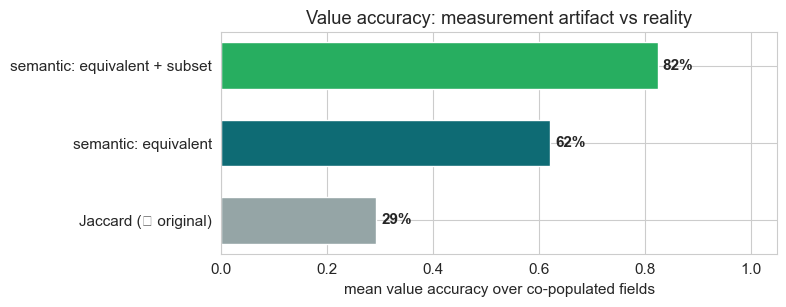

**What this shows:** the value accuracy jumps from **29%** (Jaccard) to **62%** equivalent and **82%** equivalent-or-subset. Most of the apparent failure was Jaccard penalising correct values for wording — the models are coding the *right* values far more often than the set-overlap number implied.

In [3]:

vals = [("Jaccard (⑪ original)", JAC, "#95a5a6"), ("semantic: equivalent", STRICT, "#0e6b74"),
        ("semantic: equivalent + subset", LEN, "#27ae60")]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh([v[0] for v in vals], [v[1] for v in vals], color=[v[2] for v in vals], height=0.6)
for i, (_, x, _c) in enumerate(vals): ax.text(x + 0.01, i, f"{x:.0%}", va="center", fontsize=11, fontweight="bold")
ax.set_xlim(0, 1.05); ax.set_xlabel("mean value accuracy over co-populated fields")
ax.set_title("Value accuracy: measurement artifact vs reality"); fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** the value accuracy jumps from **{JAC:.0%}** (Jaccard) to **{STRICT:.0%}** equivalent "
  f"and **{LEN:.0%}** equivalent-or-subset. Most of the apparent failure was Jaccard penalising correct values "
  f"for wording — the models are coding the *right* values far more often than the set-overlap number implied."))


## 3. Which fields were artifacts, which are real errors

Per field, two things at once. **Position:** Jaccard (x) vs semantic accuracy (y) — points high above the diagonal are pure **normalization** wins (right value, Jaccard undercounted). **Colour:** the genuine-error rate (share ruled *different*) — a red point is a real coding disagreement that normalization will *not* fix, wherever it sits. A pale point high on the diagonal is the ideal (right, just needs canonicalising); a red point is a noisy clustering covariate.

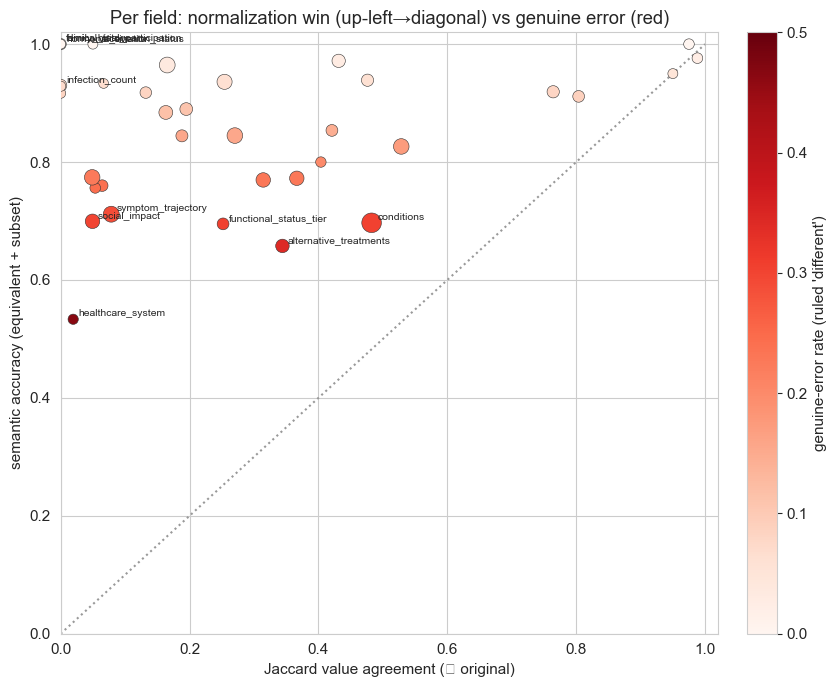

field,Jaccard,semantic (equiv),semantic (+subset),genuinely different,Jaccard→sem jump,n
healthcare_system,2%,53%,53%,47%,51%,30
alternative_treatments,34%,46%,66%,34%,31%,149
functional_status_tier,25%,37%,70%,30%,44%,82
conditions,48%,47%,70%,30%,21%,462
social_impact,5%,54%,70%,30%,65%,193
symptom_trajectory,8%,48%,71%,29%,63%,260
healthcare_costs,5%,68%,76%,24%,70%,41
diagnostic_odyssey,6%,53%,76%,24%,70%,75
mental_health,31%,57%,77%,23%,46%,191
activity_level,37%,50%,77%,23%,41%,189


In [4]:

d = fg[fg.n >= 10].copy()
fig, ax = plt.subplots(figsize=(8.5, 7))
sc = ax.scatter(d.jac, d.lenient, s=45 + d.n/3, c=d.diff_rate, cmap="Reds", vmin=0, vmax=0.5,
                edgecolor="#333", linewidth=0.4, zorder=3)
ax.plot([0,1],[0,1], ls=":", color="#999")
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04); cb.set_label("genuine-error rate (ruled 'different')")
# label the biggest normalization wins AND the reddest (real-error) fields
lab = pd.concat([d.sort_values("jump", ascending=False).head(5),
                 d.sort_values("diff_rate", ascending=False).head(6)]).drop_duplicates("field")
for _, r in lab.iterrows():
    ax.annotate(r.field, (r.jac, r.lenient), fontsize=7.5, xytext=(4,2), textcoords="offset points")
ax.set_xlabel("Jaccard value agreement (⑪ original)"); ax.set_ylabel("semantic accuracy (equivalent + subset)")
ax.set_xlim(0,1.02); ax.set_ylim(0,1.02); ax.set_title("Per field: normalization win (up-left→diagonal) vs genuine error (red)")
fig.tight_layout(); plt.show()
tbl = fg[fg.n>=10].sort_values("diff_rate", ascending=False)[["field","jac","strict","lenient","diff_rate","jump","n"]].copy()
for c in ["jac","strict","lenient","diff_rate","jump"]: tbl[c] = (tbl[c]*100).round(0).astype(int).astype(str)+"%"
tbl.columns = ["field","Jaccard","semantic (equiv)","semantic (+subset)","genuinely different","Jaccard→sem jump","n"]
display(HTML("<b>Per-field, sorted by genuine-error rate (worst first)</b>" + tbl.to_html(index=False)))


## 4. What the errors actually are

The three-way verdict split says how the co-populated values fail: equivalent (fine), a correct but less-complete subset (a recall/granularity gap, not a wrong value), or genuinely different (the real coding error).

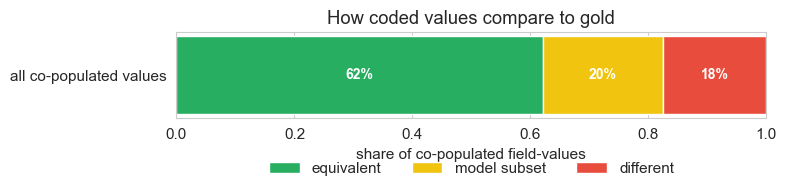

**What this shows:** only **18%** of co-populated values are genuinely wrong. **62%** mean exactly the same as gold, and **20%** are correct but less complete than Opus (a granularity gap on list fields, not a wrong value). The real coding-error rate is far below what Jaccard implied — the dominant issue is phrasing/normalization, not accuracy.

In [5]:

order = ["equivalent","model_subset","different"]; cmap = {"equivalent":"#27ae60","model_subset":"#f1c40f","different":"#e74c3c"}
counts = R.verdict.value_counts(normalize=True).reindex(order).fillna(0)
fig, ax = plt.subplots(figsize=(8, 2.4))
left = 0
for k in order:
    ax.barh(["all co-populated values"], counts[k], left=left, color=cmap[k], label=k.replace("_"," "))
    if counts[k] > 0.03: ax.text(left + counts[k]/2, 0, f"{counts[k]:.0%}", ha="center", va="center", fontsize=10, color="white", fontweight="bold")
    left += counts[k]
ax.set_xlim(0,1); ax.set_xlabel("share of co-populated field-values")
ax.legend(bbox_to_anchor=(0.5,-0.35), loc="upper center", ncol=3, frameon=False)
ax.set_title("How coded values compare to gold"); fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** only **{counts['different']:.0%}** of co-populated values are genuinely wrong. "
  f"**{counts['equivalent']:.0%}** mean exactly the same as gold, and **{counts['model_subset']:.0%}** are "
  f"correct but less complete than Opus (a granularity gap on list fields, not a wrong value). The real coding-"
  f"error rate is far below what Jaccard implied — the dominant issue is phrasing/normalization, not accuracy."))


## 5. Conclusion — a two-tier fix, and a bad-covariate watchlist

The re-score settles the earlier question, but splits it in two: a normalizable majority and a genuinely error-prone interpretive tail.

In [6]:

# per-model semantic value accuracy vs old jaccard
ms = R.groupby("model").agg(jaccard=("jac","mean"), equiv=("equiv","mean"), ok=("ok","mean"), n=("ok","size")).reset_index().sort_values("ok", ascending=False)
show = ms.copy()
for c in ["jaccard","equiv","ok"]: show[c]=(show[c]*100).round(0).astype(int).astype(str)+"%"
show.columns=["model","Jaccard","semantic equiv","semantic +subset","n values"]
display(HTML("<b>Per-model value accuracy: Jaccard vs semantic</b>" + show.to_html(index=False)))
n_art = int((fg[(fg.n>=10)].jump > 0.25).sum())
_hard = fg[(fg.n>=15) & (fg.diff_rate>=0.25)].sort_values("diff_rate", ascending=False)
_hardtxt = ", ".join(f"`{r.field}` ({r.diff_rate:.0%})" for _, r in _hard.head(6).iterrows()) or "none"
lines = [
  f"- **The scalar-field panic was a measurement artifact.** Semantically, values are **{STRICT:.0%}** equivalent "
  f"to gold and **{LEN:.0%}** equivalent-or-subset — vs {JAC:.0%} by Jaccard. Numeric/date/count fields that "
  f"scored ~0 on Jaccard for phrasing ('2' vs 'at least 2') are actually right; normalization alone fixes them.",
  f"- **But the ~{R.verdict.value_counts(normalize=True).get('different',0):.0%} genuine-error rate is real and "
  f"concentrated, not noise.** {len(_hard)} interpretive free-text fields are ruled *different* ≥25% of the time: "
  f"{_hardtxt}. These are the covariates where models genuinely disagree with Opus on **content** — normalization "
  f"will not help.",
  f"- **The fix is two-tier, not one.** (1) **Normalize** the {n_art}+ scalar/categorical fields that jump from "
  f"low Jaccard to high semantic — this is judgement ③ extended to Track-B values, plus a semantic (not "
  f"set-overlap) metric going forward. (2) **Harden the interpretive fields** — tighter schema/enums, or a judge "
  f"panel to decide whether the disagreement is model-error or Opus over-interpretation (the ⑩ single-Opus-truth "
  f"caveat bites hardest exactly here).",
  f"- **For the clustering study:** the interpretive tail above is a *bad-covariate watchlist*. Cluster on the "
  f"normalizable majority with confidence; stratify, down-weight, or exclude the red fields until a panel "
  f"resolves whether their disagreement is real.",
]
display(Markdown("### Verdict\n\n" + "\n".join(lines)))


model,Jaccard,semantic equiv,semantic +subset,n values
grok-4.5,34%,67%,90%,195
gpt-5.6-luna,17%,71%,89%,191
gpt-5.1,25%,74%,88%,215
claude-sonnet-4.6,28%,73%,87%,219
gemini-3.5-flash,34%,60%,86%,201
grok-4.20,32%,64%,84%,199
gpt-5.4-nano,15%,72%,84%,198
gpt-5-mini,25%,67%,84%,178
deepseek-v4-flash,28%,63%,83%,176
llama-4-maverick,33%,50%,83%,210


### Verdict

- **The scalar-field panic was a measurement artifact.** Semantically, values are **62%** equivalent to gold and **82%** equivalent-or-subset — vs 29% by Jaccard. Numeric/date/count fields that scored ~0 on Jaccard for phrasing ('2' vs 'at least 2') are actually right; normalization alone fixes them.
- **But the ~18% genuine-error rate is real and concentrated, not noise.** 6 interpretive free-text fields are ruled *different* ≥25% of the time: `healthcare_system` (47%), `alternative_treatments` (34%), `functional_status_tier` (30%), `conditions` (30%), `social_impact` (30%), `symptom_trajectory` (29%). These are the covariates where models genuinely disagree with Opus on **content** — normalization will not help.
- **The fix is two-tier, not one.** (1) **Normalize** the 30+ scalar/categorical fields that jump from low Jaccard to high semantic — this is judgement ③ extended to Track-B values, plus a semantic (not set-overlap) metric going forward. (2) **Harden the interpretive fields** — tighter schema/enums, or a judge panel to decide whether the disagreement is model-error or Opus over-interpretation (the ⑩ single-Opus-truth caveat bites hardest exactly here).
- **For the clustering study:** the interpretive tail above is a *bad-covariate watchlist*. Cluster on the normalizable majority with confidence; stratify, down-weight, or exclude the red fields until a panel resolves whether their disagreement is real.

## 6. Research limitations

- **Opus judges its own gold.** Opus coded the reference values and now rules on equivalence to them — mild
  circularity (verification ≠ generation, and "is 2 the same as at least 2" is fairly objective, but a second
  independent judge or a panel would tighten it). This is the same Opus-as-truth caveat flagged for ⑩.
- **"model_subset" credits incomplete lists as not-wrong** — correct for value accuracy, but a list field that
  systematically under-lists is still lossy for clustering; presence/recall (⑪) still matters alongside this.
- **Equivalence is per-value**; it does not re-check presence (whether the right fields were populated) — that
  is ⑪'s presence-F1, unchanged here.
- **Judged only co-populated fields** (both gold and model non-null); fields one side left null are a presence
  question, not a value one.
- Measures the correctness of a measurement step, not any treatment effect.

In [7]:

import hashlib as _h
try: _sha = _h.sha256(open(r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db","rb").read()).hexdigest()[:16]
except Exception: _sha = "n/a"
M = REJ["manifest"]
prov = pd.DataFrame({
  "item": ["re-score generated (UTC)","source codings","judge","candidate models","field-values judged","metric","skill version"],
  "value": [M["generated_utc"], M["source"], M["judge_model"], len(M["candidate_models"]), f"{len(R):,}",
            "semantic equivalence (equivalent | subset | different)", "research-assistant v2"],
})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect the correctness of a measurement pipeline and model knowledge, not '
             'population-level treatment effects. This is not medical advice.</div>'))


item,value
re-score generated (UTC),2026-07-18T02:56:40.664889+00:00
source codings,j11_coding_runs.json
judge,anthropic/claude-opus-4.8
candidate models,22
field-values judged,"4,237"
metric,semantic equivalence (equivalent | subset | different)
skill version,research-assistant v2
